# Model prep
Export AOO-included individuals to CSV and build dataset-level basic characteristics table (LaTeX).

In [30]:
# (1) Paths and settings
import os
import numpy as np
import pandas as pd

DATA_PATH = "../data/global40.dta"
ISO40_PATH = "../data/iso40.csv"
OUT_DIR = "../results/model_prep"
GLOBAL_CSV = "../data/globaloa.csv"

START_AGE = 50
AGE_MAX = 100

DISEASE_COLS = ["rlung", "rarthr", "rstrok", "rheart", "ralzhe", "rcancr"]
EXTRA_HEALTH_COLS = ["rdiab", "rhibp", "rcholst", "rsmoken", "rdrink"]

AGE_BINS = [50, 60, 70, 80, 200]
AGE_LABELS = ["50-59", "60-69", "70-79", "80+"]

GENDER_LABELS = {1: "Female", 2: "Male"}
URBAN_LABELS = {0: "Rural", 1: "Urban"}
EDU_LABELS = {0: "No", 1: "Yes"}
MARITAL_LABELS = {
    1: "Married",
    2: "Married, spouse absent",
    3: "Partnered",
    4: "Separated",
    5: "Divorced",
    6: "Separated/divorced",
    7: "Widowed",
    8: "Never married",
}

os.makedirs(OUT_DIR, exist_ok=True)

print("DATA_PATH:", DATA_PATH)
print("ISO40_PATH:", ISO40_PATH)
print("OUT_DIR:", OUT_DIR)
print("GLOBAL_CSV:", GLOBAL_CSV)

DATA_PATH: ../data/global40.dta
ISO40_PATH: ../data/iso40.csv
OUT_DIR: ../results/model_prep
GLOBAL_CSV: ../data/globaloa.csv


In [31]:
# (2) Load data
raw_full = pd.read_stata(DATA_PATH, convert_categoricals=False)

raw = raw_full.assign(
    id=raw_full["id"].astype(str),
    country=raw_full["isocountry_c"].astype(str),
    age=pd.to_numeric(raw_full["ragey_b"], errors="coerce"),
    rwalk1a=pd.to_numeric(raw_full.get("rwalk1a"), errors="coerce"),
    rwalksa=pd.to_numeric(raw_full.get("rwalksa"), errors="coerce"),
    rwalkra=pd.to_numeric(raw_full.get("rwalkra"), errors="coerce"),
    ragender=pd.to_numeric(raw_full.get("ragender"), errors="coerce"),
    rurbrur=pd.to_numeric(raw_full.get("rurbrur"), errors="coerce"),
    rdiab=pd.to_numeric(raw_full.get("rdiab"), errors="coerce"),
    rhibp=pd.to_numeric(raw_full.get("rhibp"), errors="coerce"),
    rcholst=pd.to_numeric(raw_full.get("rcholst"), errors="coerce"),
    rsmoken=pd.to_numeric(raw_full.get("rsmoken"), errors="coerce"),
    rdrink=pd.to_numeric(raw_full.get("rdrink"), errors="coerce"),
    raeduc=pd.to_numeric(raw_full.get("raeduc"), errors="coerce"),
    rmstat=pd.to_numeric(raw_full.get("rmstat"), errors="coerce"),
)

keep_cols = [
    "id",
    "country",
    "age",
    "rwalk1a",
    "rwalksa",
    "rwalkra",
    "ragender",
    "rurbrur",
    "raeduc",
    "rmstat",
] + DISEASE_COLS + EXTRA_HEALTH_COLS
raw = raw.loc[:, keep_cols].dropna(subset=["id", "country", "age"])
raw = raw.loc[raw["country"].str.strip() != "", :]

raw["rwalk1a"] = raw["rwalk1a"].where(raw["rwalk1a"].isin([0, 1]))
raw["rwalksa"] = raw["rwalksa"].where(raw["rwalksa"].isin([0, 1]))
raw["rwalkra"] = raw["rwalkra"].where(raw["rwalkra"].isin([0, 1]))
raw["ragender"] = raw["ragender"].where(raw["ragender"].isin([1, 2]))
raw["rurbrur"] = raw["rurbrur"].where(raw["rurbrur"].isin([0, 1]))
raw["raeduc"] = raw["raeduc"].where(raw["raeduc"].isin([0, 1]))
raw["rmstat"] = raw["rmstat"].where(raw["rmstat"].isin(list(MARITAL_LABELS.keys())))
for c in DISEASE_COLS:
    raw[c] = pd.to_numeric(raw[c], errors="coerce").where(lambda x: x.isin([0, 1]))
for c in EXTRA_HEALTH_COLS:
    raw[c] = pd.to_numeric(raw[c], errors="coerce").where(lambda x: x.isin([0, 1]))

print("raw shape:", raw.shape)
print("countries:", raw["country"].nunique())

raw shape: (1206788, 21)
countries: 40


In [3]:
# (2b) Basic characteristics of raw data (before baseline selection)
print("=" * 60)
print("RAW DATA SUMMARY (before baseline selection)")
print("=" * 60)
print(f"Total observations: {len(raw)}")
print(f"Unique individuals: {raw['id'].nunique()}")
print(f"Unique countries: {raw['country'].nunique()}")
print()

print("Age statistics:")
print(f"  Mean (SD): {raw['age'].mean():.2f} ({raw['age'].std():.2f})")
print(f"  Min/Max: {raw['age'].min():.1f} - {raw['age'].max():.1f}")
print()

print("Gender distribution:")
gender_counts = raw['ragender'].value_counts().sort_index()
for code, count in gender_counts.items():
    pct = 100 * count / raw['ragender'].notna().sum()
    print(f"  {GENDER_LABELS.get(code, f'Code {code}')}: {count} ({pct:.1f}%)")
print()

print("Urbanicity distribution:")
urban_counts = raw['rurbrur'].value_counts().sort_index()
for code, count in urban_counts.items():
    pct = 100 * count / raw['rurbrur'].notna().sum()
    print(f"  {URBAN_LABELS.get(code, f'Code {code}')}: {count} ({pct:.1f}%)")
print()

print("Disease prevalence in raw data:")
for col in DISEASE_COLS:
    n_disease = (raw[col] == 1).sum()
    n_total = raw[col].notna().sum()
    pct = 100 * n_disease / n_total if n_total > 0 else 0
    print(f"  {col}: {n_disease}/{n_total} ({pct:.1f}%)")
print()

print("Walkability variables:")
for col in ['rwalk1a', 'rwalksa', 'rwalkra']:
    n_walk = (raw[col] == 1).sum()
    n_total = raw[col].notna().sum()
    pct = 100 * n_walk / n_total if n_total > 0 else 0
    print(f"  {col}: {n_walk}/{n_total} ({pct:.1f}%)")
print("=" * 60)

RAW DATA SUMMARY (before baseline selection)
Total observations: 1206788
Unique individuals: 397182
Unique countries: 40

Age statistics:
  Mean (SD): 65.70 (11.24)
  Min/Max: 10.0 - 118.0

Gender distribution:
  Female: 513254 (43.1%)
  Male: 678015 (56.9%)

Urbanicity distribution:
  Rural: 426954 (40.8%)
  Urban: 618454 (59.2%)

Disease prevalence in raw data:
  rlung: 90198/1147827 (7.9%)
  rarthr: 399123/1156759 (34.5%)
  rstrok: 41218/960954 (4.3%)
  rheart: 105548/962943 (11.0%)
  ralzhe: 14915/729096 (2.0%)
  rcancr: 58844/945152 (6.2%)

Walkability variables:
  rwalk1a: 152067/1161601 (13.1%)
  rwalksa: 130909/466926 (28.0%)
  rwalkra: 52968/1103668 (4.8%)


In [4]:
# (3) Build AOO-included person-level baseline rows
def build_person_level_for_aoo(df_raw: pd.DataFrame) -> pd.DataFrame:
    rows = []
    df_raw = df_raw.dropna(subset=["id", "age", "country"]).copy()
    for (country, pid), g in df_raw.sort_values(["country", "id", "age"]).groupby(["country", "id"]):
        valid = g.loc[g["rwalk1a"].notna(), :]
        if valid.empty:
            continue
        baseline_idx = valid["age"].idxmin()
        baseline_row = valid.loc[baseline_idx]
        baseline_valid_age = baseline_row["age"]
        baseline_state = baseline_row["rwalk1a"]
        censor_age = valid["age"].max()
        event_age = valid.loc[valid["rwalk1a"] == 1, "age"].min() if (valid["rwalk1a"] == 1).any() else np.nan

        if pd.isna(baseline_state) or baseline_state != 0:
            continue
        if pd.isna(baseline_valid_age) or pd.isna(censor_age) or censor_age <= baseline_valid_age:
            continue
        if censor_age <= START_AGE:
            continue

        censor_age_w = min(censor_age, AGE_MAX)
        event_w = 1 if (not pd.isna(event_age) and event_age <= AGE_MAX) else 0
        exit_age = event_age if event_w == 1 else censor_age_w
        entry_age = min(max(baseline_valid_age, START_AGE), AGE_MAX)
        exit_age = min(exit_age, AGE_MAX)
        entry_t = entry_age - START_AGE
        exit_t = exit_age - START_AGE
        if pd.isna(entry_t) or pd.isna(exit_t) or exit_t <= entry_t:
            continue

        row = {
            "id": str(pid),
            "country": str(country),
            "age": float(baseline_valid_age),
            "ragender": baseline_row.get("ragender", np.nan),
            "rurbrur": baseline_row.get("rurbrur", np.nan),
            "rwalk1a": baseline_row.get("rwalk1a", np.nan),
            "rwalksa": baseline_row.get("rwalksa", np.nan),
            "rwalkra": baseline_row.get("rwalkra", np.nan),
            "raeduc": baseline_row.get("raeduc", np.nan),
            "rmstat": baseline_row.get("rmstat", np.nan),
        }
        for c in DISEASE_COLS:
            row[c] = baseline_row.get(c, np.nan)
        for c in EXTRA_HEALTH_COLS:
            row[c] = baseline_row.get(c, np.nan)
        rows.append(row)
    return pd.DataFrame(rows)

person_df = build_person_level_for_aoo(raw)
print("AOO-included persons:", len(person_df))
person_df.head()

AOO-included persons: 193731


,id,country,age,ragender,rurbrur,rwalk1a,rwalksa,rwalkra,raeduc,rmstat,...,rarthr,rstrok,rheart,ralzhe,rcancr,rdiab,rhibp,rcholst,rsmoken,rdrink
0,1.0,Australia,73.0,1.0,1.0,0.0,NaN,NaN,1.0,1.0,...,0.0,0.0,1.0,NaN,0.0,0.0,NaN,1.0,0.0,1.0
1,10.0,Australia,80.0,1.0,1.0,0.0,NaN,NaN,0.0,1.0,...,1.0,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,1.0
2,100.0,Australia,66.0,2.0,1.0,0.0,NaN,NaN,0.0,1.0,...,1.0,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,0.0
3,1000.0,Australia,80.0,1.0,1.0,0.0,NaN,NaN,0.0,1.0,...,1.0,0.0,0.0,NaN,0.0,0.0,NaN,1.0,0.0,1.0
4,1001.0,Australia,81.0,2.0,NaN,0.0,NaN,NaN,0.0,1.0,...,0.0,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,1.0


In [5]:
# (4) Export all variables for AOO-included individuals
included_ids = set(person_df["id"].astype(str).unique().tolist())
raw_full = raw_full.assign(id=raw_full["id"].astype(str))
export_df = raw_full.loc[raw_full["id"].isin(included_ids)].copy()
export_df.to_csv(GLOBAL_CSV, index=False)
print("Saved:", GLOBAL_CSV)
print("Rows exported:", len(export_df))

Saved: ../data/globaloa.csv
Rows exported: 915005


In [6]:
# (5) Basic characteristics table by dataset (LaTeX)
iso40 = pd.read_csv(ISO40_PATH)
iso40["isocountry_c"] = iso40["isocountry_c"].astype(str).str.strip()
iso40["dataset"] = iso40["dataset"].astype(str).str.strip()
iso_map = dict(zip(iso40["isocountry_c"], iso40["dataset"]))

work = person_df.copy()
work["dataset"] = work["country"].astype(str).str.strip().map(iso_map)
work["dataset"] = work["dataset"].fillna("Unknown")

raw_stats = raw_full.copy()
raw_stats["id"] = raw_stats["id"].astype(str)
raw_stats = raw_stats.loc[raw_stats["id"].isin(included_ids)].copy()
raw_stats["country"] = raw_stats["isocountry_c"].astype(str).str.strip()
raw_stats["dataset"] = raw_stats["country"].map(iso_map).fillna("Unknown")
year_col = None
for c in ["riwendy", "iwendy", "year", "iyear"]:
    if c in raw_stats.columns:
        year_col = c
        break
wave_col = "wave" if "wave" in raw_stats.columns else None
age_col = "ragey_b" if "ragey_b" in raw_stats.columns else ("agey_b" if "agey_b" in raw_stats.columns else "age")
if year_col is not None:
    raw_stats[year_col] = pd.to_numeric(raw_stats[year_col], errors="coerce")
if age_col in raw_stats.columns:
    raw_stats[age_col] = pd.to_numeric(raw_stats[age_col], errors="coerce")
if wave_col is not None:
    raw_stats[wave_col] = pd.to_numeric(raw_stats[wave_col], errors="coerce")

def _calc_followup(df: pd.DataFrame) -> float:
    if year_col is not None and year_col in df.columns:
        g = df.dropna(subset=["id", year_col]).groupby("id")[year_col].agg(["min", "max"])
        if g.empty:
            return np.nan
        return float((g["max"] - g["min"]).mean())
    if age_col in df.columns:
        g = df.dropna(subset=["id", age_col]).groupby("id")[age_col].agg(["min", "max"])
        if g.empty:
            return np.nan
        return float((g["max"] - g["min"]).mean())
    return np.nan

stats_map = {}
for ds, sub in raw_stats.groupby("dataset"):
    start_year = np.nan
    end_year = np.nan
    if year_col is not None and year_col in sub.columns:
        start_year = sub[year_col].min()
        end_year = sub[year_col].max()
    waves = sub[wave_col].max() if wave_col is not None and wave_col in sub.columns else np.nan
    fu_mean = _calc_followup(sub)
    stats_map[ds] = {
        "start_year": start_year,
        "end_year": end_year,
        "waves": waves,
        "followup": fu_mean,
    }
stats_map["Total"] = {
    "start_year": raw_stats[year_col].min() if year_col is not None and year_col in raw_stats.columns else np.nan,
    "end_year": raw_stats[year_col].max() if year_col is not None and year_col in raw_stats.columns else np.nan,
    "waves": raw_stats[wave_col].max() if wave_col is not None and wave_col in raw_stats.columns else np.nan,
    "followup": _calc_followup(raw_stats),
}

def fmt_mean_sd(series: pd.Series) -> str:
    s = series.dropna()
    if len(s) == 0:
        return "--"
    return f"{s.mean():.2f}\\\\({s.std(ddof=1):.2f})"

def fmt_binary(series: pd.Series, value=1, show_zero: bool = True) -> str:
    s = series.dropna()
    n = len(s)
    if n == 0:
        return "--"
    count = int((s == value).sum())
    if count == 0 and not show_zero:
        return "--"
    pct = 100.0 * count / n
    return f"{count}\\\\({pct:.2f}\\%)"

def fmt_stat(val, fmt: str = "{:.1f}") -> str:
    if pd.isna(val):
        return "--"
    return fmt.format(val)

row_labels = [
    "n",
    "Start year",
    "End year",
    "Waves",
    "Follow-up years (mean)",
    "Age (s.d.)",
    "Gender Female",
    "Gender Male",
    "Tertiary education No",
    "Tertiary education Yes",
    "Marital Married",
    "Marital Married, spouse absent",
    "Marital Partnered",
    "Marital Separated",
    "Marital Divorced",
    "Marital Separated/divorced",
    "Marital Widowed",
    "Marital Never married",
    "Region Rural",
    "Region Urban",
    "rlung",
    "rarthr",
    "rstrok",
    "rheart",
    "ralzhe",
    "rcancr",
    "rdiab",
    "rhibp",
    "rcholst",
    "rsmoken",
    "rdrink",
]

table = pd.DataFrame(index=row_labels)

def build_col(sub: pd.DataFrame, ds_name: str) -> dict:
    col = {}
    col["n"] = str(len(sub))
    stats = stats_map.get(ds_name, {})
    col["Start year"] = fmt_stat(stats.get("start_year", np.nan), "{:.0f}")
    col["End year"] = fmt_stat(stats.get("end_year", np.nan), "{:.0f}")
    col["Waves"] = fmt_stat(stats.get("waves", np.nan), "{:.0f}")
    col["Follow-up years (mean)"] = fmt_stat(stats.get("followup", np.nan), "{:.1f}")
    col["Age (s.d.)"] = fmt_mean_sd(sub["age"])
    for k, lab in GENDER_LABELS.items():
        col[f"Gender {lab}"] = fmt_binary(sub["ragender"], k)
    for k, lab in URBAN_LABELS.items():
        col[f"Region {lab}"] = fmt_binary(sub["rurbrur"], k)
    for k, lab in EDU_LABELS.items():
        col[f"Tertiary education {lab}"] = fmt_binary(sub["raeduc"], k)
    for k, lab in MARITAL_LABELS.items():
        col[f"Marital {lab}"] = fmt_binary(sub["rmstat"], k, show_zero=False)
    for c in DISEASE_COLS:
        col[c] = fmt_binary(sub[c], 1)
    for c in EXTRA_HEALTH_COLS:
        col[c] = fmt_binary(sub[c], 1)
    return col

table["Total"] = pd.Series(build_col(work, "Total"))

desired_order = ["HRS", "SHARE", "ELSA", "ALSA", "CHARLS", "NSJE+MIDJA", "KLOSA", "LASI", "MHAS"]
final_order = desired_order
for ds in final_order:
    if ds in set(work["dataset"].dropna().unique()):
        sub = work[work["dataset"] == ds].copy()
        table[ds] = pd.Series(build_col(sub, ds))
    else:
        table[ds] = pd.Series(["--"] * len(row_labels), index=row_labels)

col_order = ["Total"] + final_order
table = table[col_order]

def _shortstack(val: str) -> str:
    if val in ("", "--") or pd.isna(val):
        return "--"
    return f"\\shortstack[t]{{{val}}}"

latex_lines = []
latex_lines.append("\\begin{table}[htbp]")
latex_lines.append("\\centering")
latex_lines.append("\\caption{Baseline characteristics of participants across cohorts.}")
latex_lines.append("\\label{tab:baseline_characteristics}")
latex_lines.append("\\footnotesize")
latex_lines.append("\\setlength{\\tabcolsep}{2pt}")
latex_lines.append("\\renewcommand{\\arraystretch}{1.05}")
latex_lines.append("")
latex_lines.append("% \\rowcolors{2}{gray!20}{white}")
latex_lines.append("")
latex_lines.append("\\begin{tabular}{>{\\raggedright\\arraybackslash}p{2cm}*")
latex_lines.append("{10}{>{\\centering\\arraybackslash}p{1.32cm}}}")
latex_lines.append("\\toprule")
header_cells = ["", "\\textbf{Total}", "\\textbf{HRS}", "\\textbf{SHARE}", "\\textbf{ELSA}", "\\textbf{ALSA}", "\\textbf{CHARLS}", "\\shortstack{\\textbf{NSJE+}\\\\\\textbf{MIDJA}}", "\\textbf{KLOSA}", "\\textbf{LASI}", "\\textbf{MHAS}"]
latex_lines.append(" & ".join(header_cells) + " \\\\ ")
latex_lines.append("\\midrule")
latex_lines.append("")

def _row_cells(key: str) -> list:
    vals = [_shortstack(table.loc[key, c]) for c in col_order]
    return vals

def _render_row(label: str, key: str, rowcolor: bool = False) -> str:
    prefix = "\\rowcolor{gray!15}\n" if rowcolor else ""
    cells = _row_cells(key)
    return prefix + label + " & " + " & ".join(cells) + " \\\\ "

latex_lines.append(_render_row("\\textbf{n}", "n", rowcolor=False))
latex_lines.append(_render_row("\\textbf{Start year}", "Start year", rowcolor=True))
latex_lines.append(_render_row("\\textbf{End year}", "End year", rowcolor=False))
latex_lines.append(_render_row("\\textbf{Waves}", "Waves", rowcolor=True))
latex_lines.append(_render_row("\\textbf{Follow-up years}", "Follow-up years (mean)", rowcolor=False))
latex_lines.append(_render_row("\\textbf{Age (s.d.)}", "Age (s.d.)", rowcolor=True))
latex_lines.append("\\addlinespace[0.2em]")
latex_lines.append("\\textbf{Gender} \\\\ ")
latex_lines.append(_render_row("\\quad Female", "Gender Female", rowcolor=True))
latex_lines.append(_render_row("\\quad Male", "Gender Male", rowcolor=False))
latex_lines.append("")
latex_lines.append("\\addlinespace[0.2em]")
latex_lines.append("\\textbf{Tertiary education} \\\\ ")
latex_lines.append(_render_row("\\quad No", "Tertiary education No", rowcolor=True))
latex_lines.append(_render_row("\\quad Yes", "Tertiary education Yes", rowcolor=False))
latex_lines.append("")
latex_lines.append("\\addlinespace[0.3em]")
latex_lines.append("\\textbf{Marital status} \\\\ ")
latex_lines.append(_render_row("\\quad Married", "Marital Married", rowcolor=True))
latex_lines.append(_render_row("\\quad \\shortstack[l]{Married,\\\\spouse absent}", "Marital Married, spouse absent", rowcolor=False))
latex_lines.append(_render_row("\\quad Partnered", "Marital Partnered", rowcolor=True))
latex_lines.append(_render_row("\\quad Separated", "Marital Separated", rowcolor=False))
latex_lines.append(_render_row("\\quad Divorced", "Marital Divorced", rowcolor=True))
latex_lines.append(_render_row("\\quad \\shortstack[l]{Separated/\\\\divorced}", "Marital Separated/divorced", rowcolor=False))
latex_lines.append(_render_row("\\quad \\shortstack[t]{Widowed}", "Marital Widowed", rowcolor=True))
latex_lines.append(_render_row("\\quad \\shortstack[l]{Never\\\\married}", "Marital Never married", rowcolor=False))
latex_lines.append("")
latex_lines.append("\\addlinespace[0.2em]")
latex_lines.append("\\textbf{Region} \\\\ ")
latex_lines.append(_render_row("\\quad Rural", "Region Rural", rowcolor=True))
latex_lines.append(_render_row("\\quad Urban", "Region Urban", rowcolor=False))
latex_lines.append("")
latex_lines.append("\\addlinespace[0.2em]")
latex_lines.append("\\textbf{Health} \\\\ ")
latex_lines.append(_render_row("\\quad Lung disease", "rlung", rowcolor=True))
latex_lines.append(_render_row("\\quad Arthritis", "rarthr", rowcolor=False))
latex_lines.append(_render_row("\\quad Stroke", "rstrok", rowcolor=True))
latex_lines.append(_render_row("\\quad Heart disease", "rheart", rowcolor=False))
latex_lines.append(_render_row("\\quad \\shortstack[l]{Alzheimer's\\\\disease}", "ralzhe", rowcolor=True))
latex_lines.append(_render_row("\\quad Cancer", "rcancr", rowcolor=False))
latex_lines.append(_render_row("\\quad Diabetes", "rdiab", rowcolor=True))
latex_lines.append(_render_row("\\quad Hypertension", "rhibp", rowcolor=False))
latex_lines.append(_render_row("\\quad \\shortstack[l]{High\\\\cholesterol}", "rcholst", rowcolor=True))
latex_lines.append(_render_row("\\quad Smoking", "rsmoken", rowcolor=False))
latex_lines.append(_render_row("\\quad Drinking", "rdrink", rowcolor=True))
latex_lines.append("\\bottomrule")
latex_lines.append("\\end{tabular}")
latex_lines.append("\\end{table}")
latex = "\n".join(latex_lines)

out_tex = os.path.join(OUT_DIR, "basic_characteristics.tex")
with open(out_tex, "w", encoding="utf-8") as f:
    f.write(latex)
print("Saved LaTeX table:", out_tex)
table.head(40)

Saved LaTeX table: ../results/model_prep/basic_characteristics.tex


,Total,HRS,SHARE,ELSA,ALSA,CHARLS,NSJE+MIDJA,KLOSA,LASI,MHAS
n,193731,32935,96990,13620,1460,17999,2597,9359,2264,16507
Start year,1987,1992,2004,2002,1992,2011,1987,2006,2017,2001
End year,2024,2023,2022,2019,2014,2018,2011,2020,2024,2019
Waves,16,16,9,9,13,4,6,8,2,5
Follow-up years (mean),9.4,14.4,7.9,10.1,8.3,6.1,7.7,11.1,6.0,10.8
Age (s.d.),61.22\\(9.80),58.62\\(10.10),62.78\\(9.50),60.82\\(9.56),76.70\\(6.55),58.28\\(9.25),66.11\\(7.15),60.45\\(10.35),65.64\\(7.03),58.42\\(8.54)
Gender Female,87516\\(45.34\%),14787\\(44.90\%),43521\\(44.87\%),6186\\(45.42\%),768\\(52.60\%),8949\\(49.72\%),807\\(42.79\%),4124\\(44.06\%),1042\\(46.02\%),7332\\(44.42\%)
Gender Male,105504\\(54.66\%),18148\\(55.10\%),53469\\(55.13\%),7434\\(54.58\%),692\\(47.40\%),9050\\(50.28\%),1079\\(57.21\%),5235\\(55.94\%),1222\\(53.98\%),9175\\(55.58\%)
Tertiary education No,147325\\(77.48\%),18114\\(55.01\%),75091\\(77.42\%),10153\\(82.00\%),917\\(62.98\%),17623\\(97.91\%),208\\(54.74\%),8321\\(88.91\%),2176\\(96.11\%),14722\\(89.86\%)
Tertiary education Yes,42814\\(22.52\%),14812\\(44.99\%),21899\\(22.58\%),2228\\(18.00\%),539\\(37.02\%),376\\(2.09\%),172\\(45.26\%),1038\\(11.09\%),88\\(3.89\%),1662\\(10.14\%)


In [7]:
# (6) Last survey year by country
year_col = None
for c in ["riwendy", "iwendy", "year", "iyear"]:
    if c in raw_full.columns:
        year_col = c
        break
country_col = "isocountry_c" if "isocountry_c" in raw_full.columns else ("country" if "country" in raw_full.columns else None)

if year_col is None or country_col is None:
    print("Missing year or country column. year_col:", year_col, "country_col:", country_col)
else:
    tmp = raw_full.loc[:, [country_col, year_col]].copy()
    tmp[country_col] = tmp[country_col].astype(str).str.strip()
    tmp[year_col] = pd.to_numeric(tmp[year_col], errors="coerce")
    tmp = tmp.dropna(subset=[country_col, year_col])
    last_year = (
        tmp.groupby(country_col, as_index=False)[year_col]
        .max()
        .rename(columns={country_col: "country", year_col: "last_survey_year"})
        .sort_values("country")
    )
    out_csv = os.path.join(OUT_DIR, "last_survey_year_by_country.csv")
    last_year.to_csv(out_csv, index=False)
    print("Saved:", out_csv)
    print(last_year.head(40))

Saved: ../results/model_prep/last_survey_year_by_country.csv
           country  last_survey_year
0        Australia            2014.0
1          Austria            2022.0
2          Belgium            2022.0
3           Brazil            2020.0
4         Bulgaria            2022.0
5            China            2018.0
6       Costa Rica            2014.0
7          Croatia            2022.0
8           Cyprus            2022.0
9   Czech Republic            2022.0
10         Denmark            2022.0
11         England            2019.0
12         Estonia            2022.0
13         Finland            2022.0
14          France            2022.0
15         Germany            2022.0
16          Greece            2022.0
17         Hungary            2022.0
18           India            2024.0
19         Ireland            2007.0
20          Israel            2022.0
21           Italy            2022.0
22           Japan            2011.0
23           Korea            2020.0
24          La

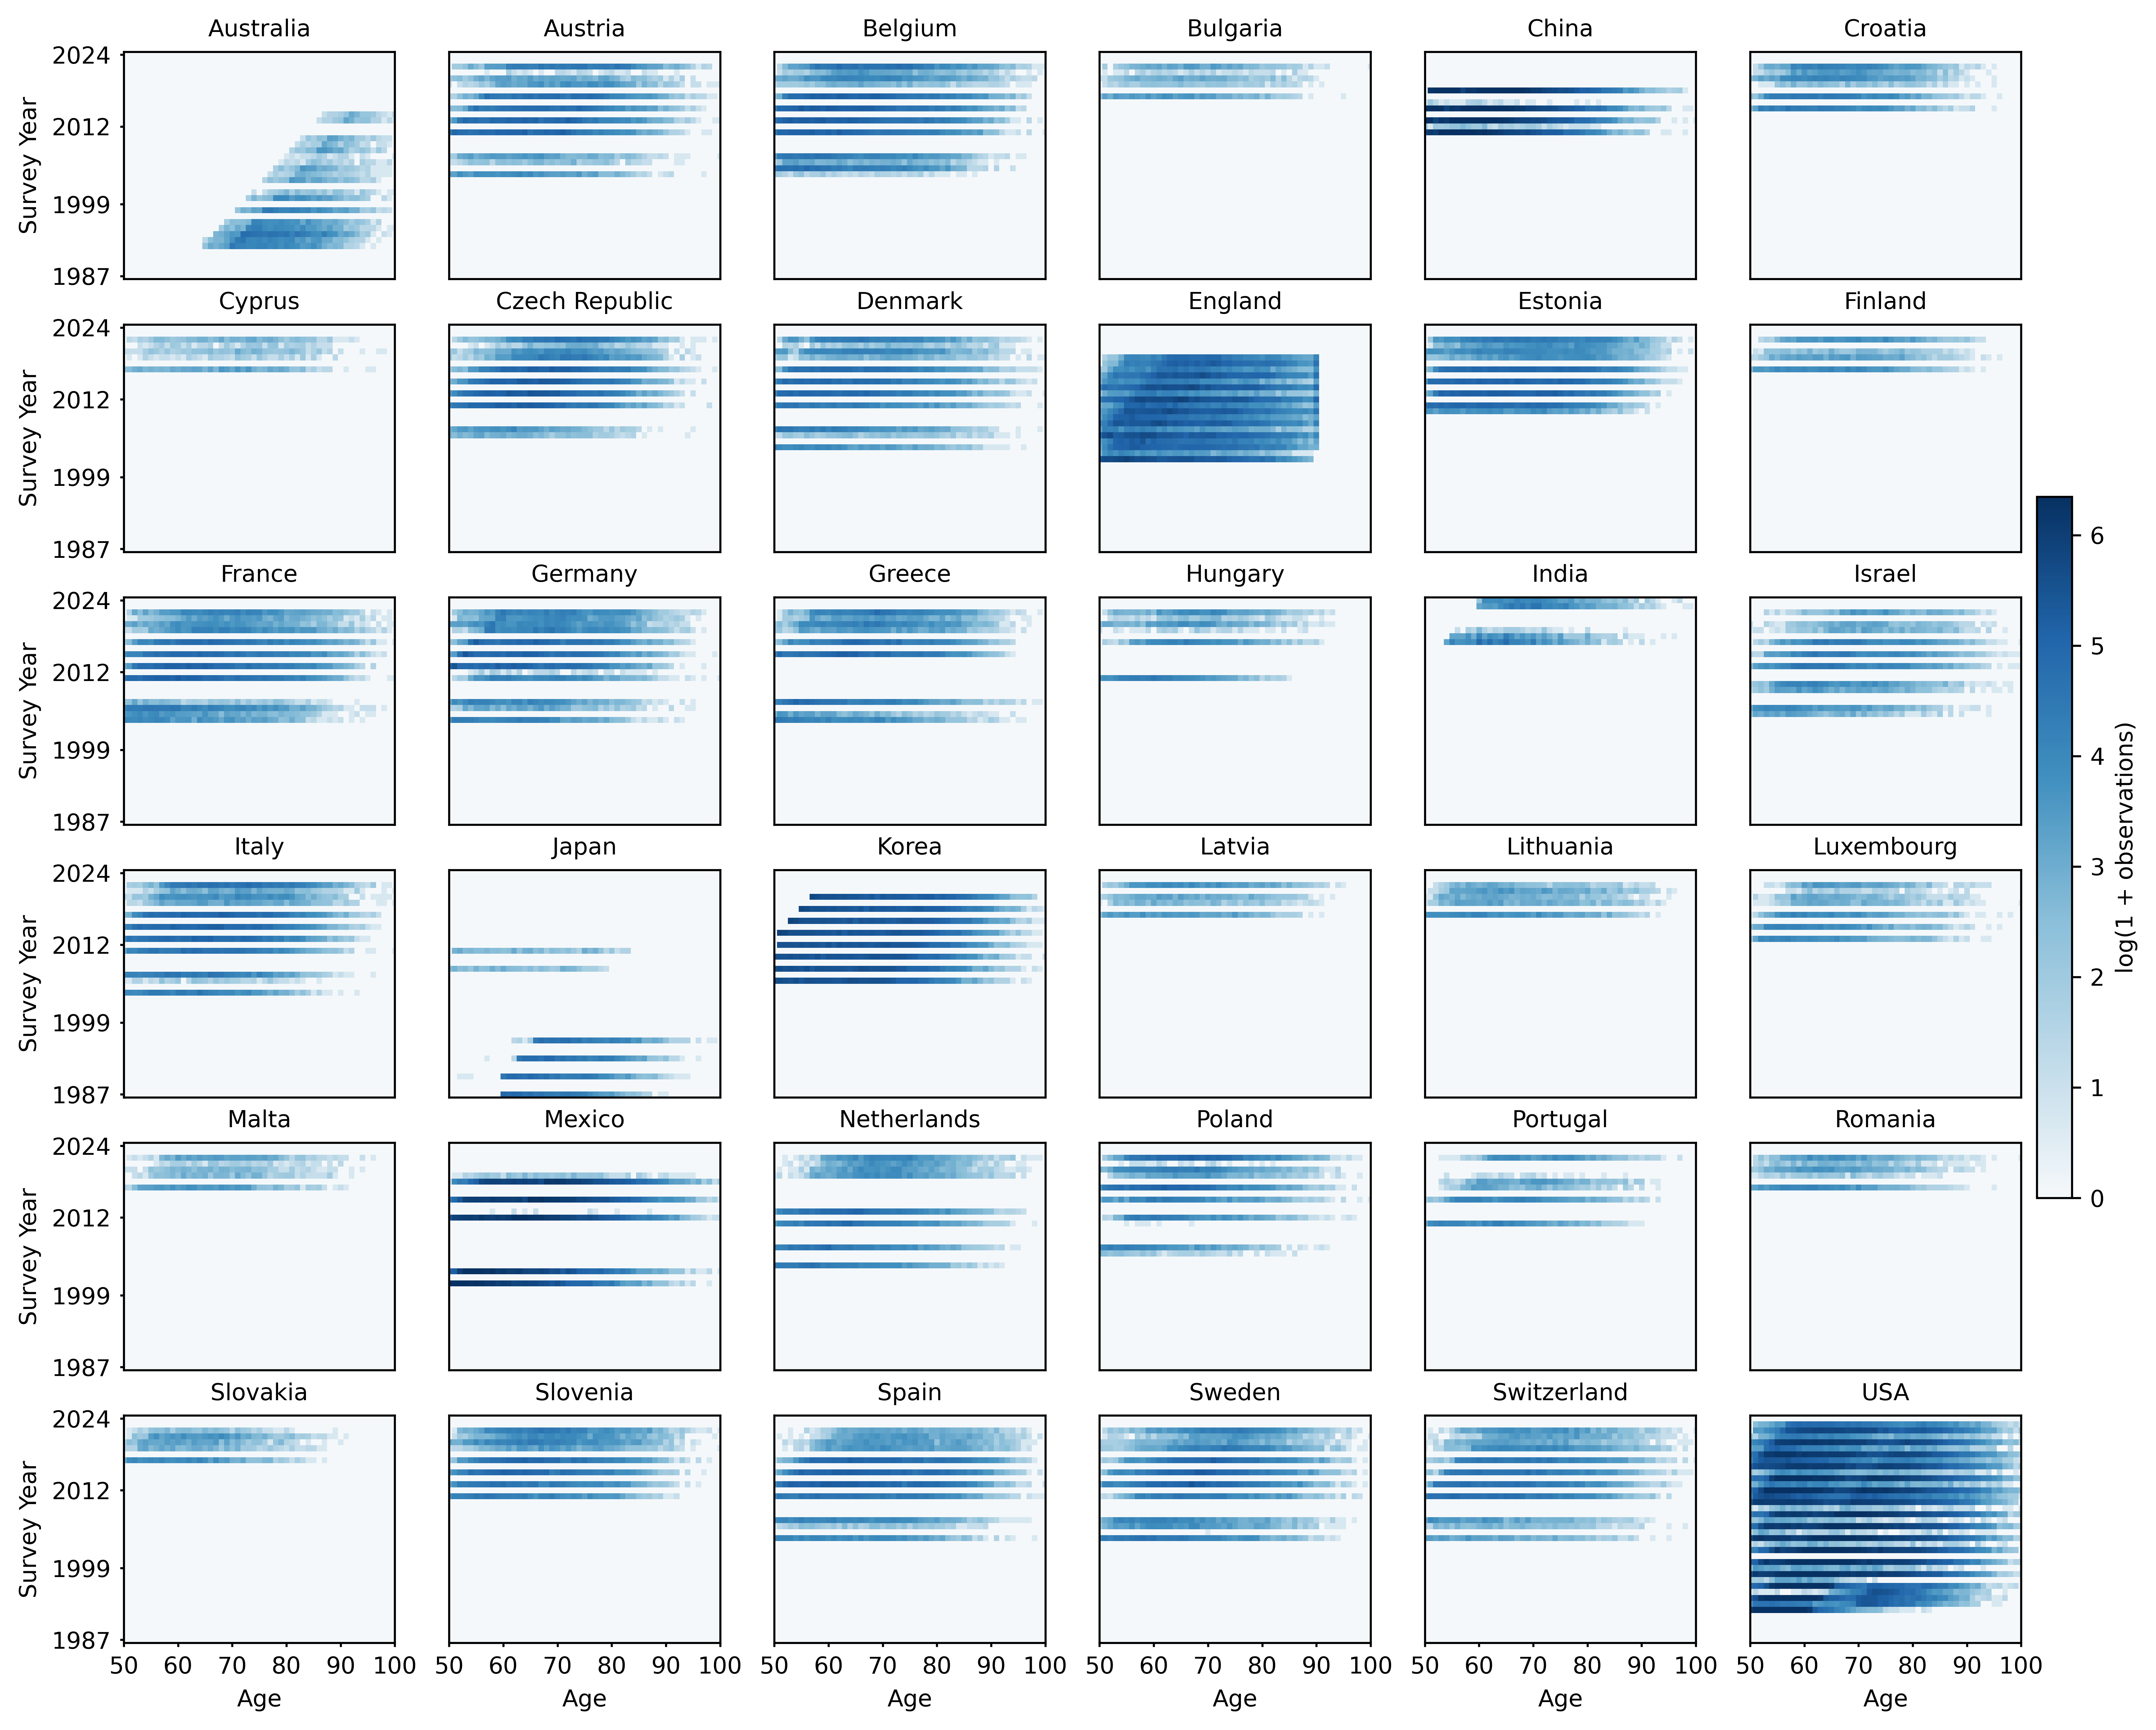

Saved: ../results/model_prep/country_age_by_riwendy_heatmap.pdf
Saved: ../results/model_prep/country_age_by_riwendy_counts.csv
Countries plotted: 36


In [34]:
# (7) Country age-by-year heatmaps
import math
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.backends.backend_pdf import PdfPages

HEATMAP_OUT = os.path.join(OUT_DIR, "country_age_by_riwendy_heatmap.pdf")
HEATMAP_CSV = os.path.join(OUT_DIR, "country_age_by_riwendy_counts.csv")
HEATMAP_CMAP = LinearSegmentedColormap.from_list(
    "custom_age_year",
    ["#F5F8FA", "#BFDAE9", "#89BED9", "#408FBF", "#2165AA", "#073162"],
)

country_col = "isocountry_c" if "isocountry_c" in raw_full.columns else ("country" if "country" in raw_full.columns else None)
year_col = "riwendy" if "riwendy" in raw_full.columns else None
age_col = "ragey_b" if "ragey_b" in raw_full.columns else ("agey_b" if "agey_b" in raw_full.columns else "age")

if country_col is None or year_col is None or age_col not in raw_full.columns:
    print("Missing required columns:", {"country_col": country_col, "year_col": year_col, "age_col": age_col})
else:
    heat = raw_full.loc[:, ["id", country_col, year_col, age_col]].copy()
    heat["id"] = heat["id"].astype(str)
    heat["country"] = heat[country_col].astype(str).str.strip()
    heat["riwendy"] = pd.to_numeric(heat[year_col], errors="coerce")
    heat["age"] = pd.to_numeric(heat[age_col], errors="coerce")
    heat = heat.dropna(subset=["country", "riwendy", "age"])
    heat = heat.loc[heat["country"] != "", :].copy()

    # Keep the same analytic sample as the basic-characteristics table when available.
    if "included_ids" in globals():
        heat = heat.loc[heat["id"].isin(included_ids)].copy()
        sample_label = "AOO-included individuals"
    else:
        sample_label = "all observations"

    heat["riwendy"] = heat["riwendy"].round().astype(int)
    heat["age"] = heat["age"].round().astype(int)
    heat = heat.loc[(heat["age"] >= START_AGE) & (heat["age"] <= AGE_MAX), :].copy()

    counts = (
        heat.groupby(["country", "riwendy", "age"])
        .size()
        .rename("n")
        .reset_index()
        .sort_values(["country", "riwendy", "age"])
    )
    counts.to_csv(HEATMAP_CSV, index=False)

    countries = sorted(counts["country"].unique())
    ncols = 6
    nrows = math.ceil(len(countries) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(2.25 * ncols, 1.85 * nrows), dpi=600, squeeze=False)
    axes_flat = axes.ravel()

    age_values = np.arange(START_AGE, AGE_MAX + 1)
    year_values = np.arange(counts["riwendy"].min(), counts["riwendy"].max() + 1)
    vmax = np.log1p(counts["n"].quantile(0.99)) if not counts.empty else 1
    im = None

    for ax_idx, ax in enumerate(axes_flat):
        if ax_idx >= len(countries):
            ax.set_visible(False)
            continue

        country = countries[ax_idx]
        sub = counts.loc[counts["country"] == country]
        mat = (
            sub.pivot_table(index="riwendy", columns="age", values="n", aggfunc="sum", fill_value=0)
            .reindex(index=year_values, columns=age_values, fill_value=0)
        )
        plot_mat = np.log1p(mat.to_numpy(dtype=float))
        im = ax.imshow(
            plot_mat,
            aspect="auto",
            origin="lower",
            cmap=HEATMAP_CMAP,
            vmin=0,
            vmax=vmax,
            extent=[age_values.min() - 0.5, age_values.max() + 0.5, year_values.min() - 0.5, year_values.max() + 0.5],
        )
        ax.set_title(country, fontsize=9)
        ax.set_xlim(START_AGE, AGE_MAX)
        ax.set_xticks([50, 60, 70, 80, 90, 100])
        y_ticks = np.linspace(year_values.min(), year_values.max(), num=min(4, len(year_values))).round().astype(int)
        ax.set_yticks(y_ticks)

        is_left_col = (ax_idx % ncols == 0)
        is_bottom_row = (ax_idx // ncols == nrows - 1)
        ax.tick_params(axis="both", labelsize=9, length=1.5)
        ax.tick_params(axis="y", labelleft=is_left_col, left=is_left_col)
        ax.tick_params(axis="x", labelbottom=is_bottom_row, bottom=is_bottom_row)
        ax.set_xlabel("Age" if is_bottom_row else "", fontsize=9)
        ax.set_ylabel("Survey Year" if is_left_col else "", fontsize=9)

    if im is not None:
        cbar = fig.colorbar(im, ax=axes_flat.tolist(), fraction=0.018, pad=0.008)
        cbar.set_label("log(1 + observations)", fontsize=9)
        cbar.ax.tick_params(labelsize=9)

    # fig.suptitle(f"Age distribution by survey year", fontsize=12, y=0.95)
    fig.savefig(HEATMAP_OUT, bbox_inches="tight")
    plt.show()
    print("Saved:", HEATMAP_OUT)
    print("Saved:", HEATMAP_CSV)
    print("Countries plotted:", len(countries))
